In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
fake_df = pd.read_csv(r"C:\Users\mudda\Downloads\archive (19)\News _dataset\Fake.csv")
true_df = pd.read_csv(r"C:\Users\mudda\Downloads\archive (19)\News _dataset\True.csv")

# Getting information from the datasets

In [3]:
fake_df.sample(10)

,title,text,subject,date
18658,THE MOMENT FBI Director James Comey Lost All C...,Hillary Clinton was dogged throughout her camp...,left-news,"May 9, 2017"
3083,Trump’s America: Jewish Centers Rattled With ...,"In Trump s new America, hate and violence are ...",News,"January 9, 2017"
23163,Henningsen: ‘US Anti-Trump Protests Similar to...,21st Century Wire says Organized efforts are u...,Middle-east,"November 12, 2016"
12409,EPIC LIBERAL SMACKDOWN: “Burning Up The Street...,,politics,"Nov 13, 2016"
5620,Here Are Three Of The White Supremacists On T...,Donald Trump s reputation as a disgusting raci...,News,"July 3, 2016"
17068,RAND PAUL Picks Fight With Wrong Senator: Says...,Here s a newsflash Rand We re not looking for ...,Government News,"Oct 1, 2015"
5260,Trump Mocked Mercilessly After He Tries (And ...,Donald Trump is not a detail person. Learning ...,News,"July 30, 2016"
1466,James Clapper Just Publicly Said Trump Is Des...,Donald Trump has been throwing around the fals...,News,"May 14, 2017"
2870,FBI Clears Michael Flynn Of Wrongdoing As Tru...,"On Tuesday, it was announced that Donald Trump...",News,"January 24, 2017"
2178,GOP Rep. Steve King Just Went FULL White Supr...,While it should surprise absolutely no one tha...,News,"March 12, 2017"


In [4]:
true_df.sample(10)

,title,text,subject,date
17361,Bill Clinton called to break Northern Ireland ...,BELFAST (Reuters) - Former U.S. President Bill...,worldnews,"October 16, 2017"
2005,"Holding keys to debt limit, Democrats weigh ta...",WASHINGTON (Reuters) - Democrats in the U.S. C...,politicsNews,"August 25, 2017"
5562,China says attaches great importance to ties a...,BEIJING (Reuters) - China said on Thursday it ...,politicsNews,"February 9, 2017"
7866,U.S. must stop judicial 'extortion' of corpora...,PARIS (Reuters) - Europe should challenge the ...,politicsNews,"October 11, 2016"
14794,Plane crash in Russia's far east kills six: re...,MOSCOW (Reuters) - Six people were killed when...,worldnews,"November 15, 2017"
2331,Senate reauthorizes FDA to collect fees from d...,(Reuters) - The U.S. Senate on Thursday passed...,politicsNews,"August 3, 2017"
1591,"Despite undiplomatic discourse, Trump's dance ...",UNITED NATIONS (Reuters) - A subtle diplomat l...,politicsNews,"September 22, 2017"
13883,Next round of Syria peace talks in Geneva to b...,RIYADH (Reuters) - The next round of U.N.-back...,worldnews,"November 24, 2017"
15283,Graft suspected in Indonesian anti-corruption ...,JAKARTA (Reuters) - An Indonesian prosecutor h...,worldnews,"November 9, 2017"
19156,New Zealand Labour leader says will reach out ...,WELLINGTON (Reuters) - New Zealand s Labour Pa...,worldnews,"September 25, 2017"


In [7]:
fake_df.info(),true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


(None, None)

In [8]:
fake_df.isnull().sum(),true_df.isnull().sum()

(title      0
 text       0
 subject    0
 date       0
 dtype: int64,
 title      0
 text       0
 subject    0
 date       0
 dtype: int64)

In [9]:
fake_df.duplicated().sum(),true_df.duplicated().sum()

(np.int64(3), np.int64(206))

### dropping the completely duplicated rows 

In [11]:
fake_df.drop_duplicates(inplace=True)

In [13]:
true_df.drop_duplicates(inplace=True)

### As there is no actual way of identufying the true and false news, so we add labels to both the dataset representing thier type

In [15]:
fake_df['label'] = 1
true_df['label'] = 0

### Dropping date as it provides no use to our model building

In [ ]:
fake_df = fake_df.drop(columns=['date'])
true_df = true_df.drop(columns=['date'])

### combining true and false news datasets to get final data set

In [19]:
df = pd.concat([fake_df,true_df],axis=0)

In [23]:
df.sample(10)

,title,text,subject,label
10322,HEARTBREAKING: Baby Charlie Gard’s Parents End...,This news is heartbreaking because it s the un...,politics,1
7142,GOP Freak Show? Watch Ted Cruz Have The Uncan...,"While speaking in Fargo, North Dakota, Ted Cru...",News,1
8488,Gross: How GOP Candidates Are Using Military ...,At least two Republican campaigns are using ve...,News,1
23366,BREAKING BAD: John McCain’s Campaign Rocked by...,21st Century Wire asks Will this be the beginn...,Middle-east,1
4994,GOP Starts OPENLY Admitting That They Royally...,Trump s appointment of Breitbart chief Steve B...,News,1
908,Mike Pence Saw ‘DO NOT TOUCH’ On Critical NAS...,We already knew Vice President Mike Pence does...,News,1
10649,Clinton opposes recommendation to drop limits ...,"COLUMBIA, S.C. (Reuters) - A top adviser to De...",politicsNews,0
20448,WATCH THIS: DID GOOGLE MANIPULATE Search For H...,While researching for a wrap-up on the June 7 ...,left-news,1
21304,U.S. navy recovers remains of all sailors miss...,SINGAPORE (Reuters) - The U.S. Navy on Monday ...,worldnews,0
15408,Philippines' Duterte to raise sea dispute with...,MANILA (Reuters) - Philippine President Rodrig...,worldnews,0


### combining the title and the text as model will benefit from having one text heavy feature with same sentiment

In [25]:
df['content'] = df['title'] + ' ' + df['text']

In [27]:
df.drop(columns=['title','text'],inplace=True)

### removing outliers

In [72]:
df['word_counts'].describe()

count    43947.000000
mean       424.241200
std        350.788664
min         21.000000
25%        226.000000
50%        378.000000
75%        529.000000
max       8148.000000
Name: word_counts, dtype: float64

In [61]:
df = df[df['word_counts'] > 20]

### We remove the shorter outliers as they do not help in model building but keep the longer ones because they can contribute to gaining usefull information in model building

In [63]:
df.sample(10)

,subject,label,content,word_counts
7128,politicsNews,0,Trump picks regulation opponents to lead FCC t...,651
8148,politicsNews,0,"Powell reveals disgust with Trump, distaste fo...",700
16147,worldnews,0,Iran to lift border curbs with Iraq's Kurdish ...,245
6501,politicsNews,0,Comey defends actions during 'challenging' U.S...,210
12128,worldnews,0,South Africa's nearly man Ramaphosa may lead c...,966
15772,worldnews,0,"World 'running out of time' on North Korea, Tr...",628
6180,politicsNews,0,"On Inauguration Eve, Trumpsters party in the '...",646
14846,politics,1,SHE SHOULD NEVER HAVE BEEN ALLOWED To Step Foo...,537
5597,politicsNews,0,Trump travel restrictions hit demand for visit...,325
22802,Middle-east,1,Liberal Imperium: Quigley’s Anglo-American Est...,242


### our final dataset is ready for model building

# Exploratory Data Analysis

### How many news are fake and how many news are actually true

(label
 1    22737
 0    21210
 Name: count, dtype: int64,
 <Axes: xlabel='label'>)

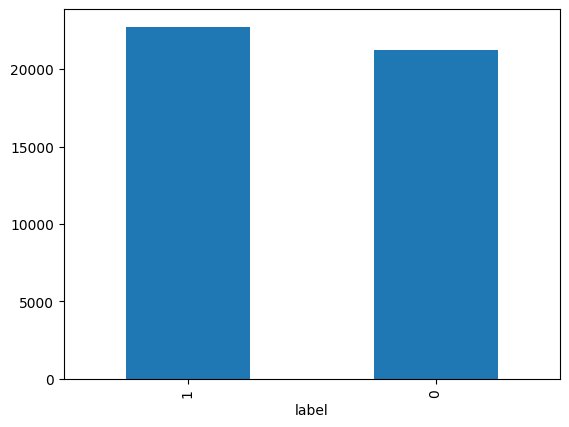

In [64]:
df['label'].value_counts(),df['label'].value_counts().plot(kind='bar')

In [65]:
df['label'].value_counts(normalize=True)*100

label
1    51.73732
0    48.26268
Name: proportion, dtype: float64

### from this we can say that out data set is pretty balanced 

### How many words in fake news compared to real news

In [71]:
df.loc[:, 'word_count'] = df['content'].apply(lambda x: len(x.split()))

C:\Users\mudda\AppData\Local\Temp\ipykernel_13324\4121549113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'word_count'] = df['content'].apply(lambda x: len(x.split()))


<Axes: xlabel='label'>

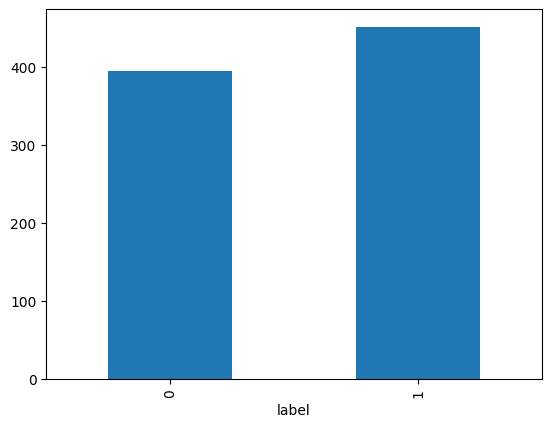

In [67]:
# compare average word lenght
df.groupby('label')['word_counts'].mean().plot(kind='bar')

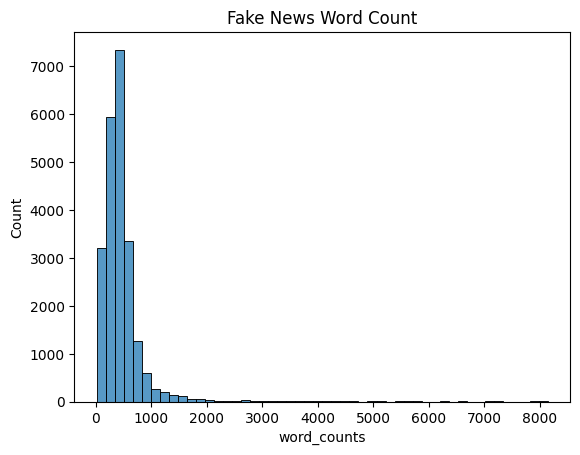

In [68]:
sns.histplot(df[df['label'] == 1]['word_counts'], bins=50)
plt.title("Fake News Word Count")
plt.show()

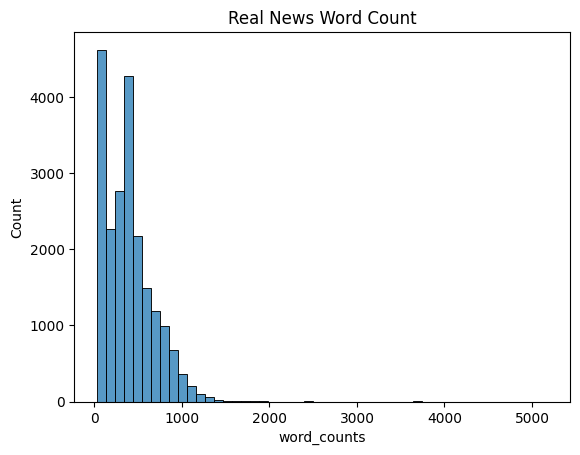

In [69]:
sns.histplot(df[df['label'] == 0]['word_counts'], bins=50)
plt.title("Real News Word Count")
plt.show()

### Fake news articles show a longer right tail and more extreme word counts compared to real news, suggesting fake articles often use extended, emotionally driven narratives.

### Lets see what category do most of the fake news belong to

In [82]:
pd.crosstab(df['label'],df['subject'])

subject,Government News,Middle-east,News,US_News,left-news,politics,politicsNews,worldnews
label,,,,,,,,
0,0,0,0,0,0,0,11219,9991
1,1491,778,9050,783,4279,6356,0,0


### Subject distribution revealed strong dataset bias where certain subjects appear exclusively in fake or real classes. To avoid data leakage and ensure the model learns linguistic patterns rather than metadata shortcuts, the subject feature was excluded.

### Hence we drop the subject column

In [ ]:
df = df.drop(columns=['subject'])

# NLP Text Preprocessing

In [87]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

In [90]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [91]:
def preprocess(text):
    text = text.lower()                                  # lowercase
    text = re.sub(r'<.*?>', '', text)                    # remove html
    text = re.sub(r'http\S+|www\S+', '', text)           # remove urls
    text = re.sub(r'[^a-zA-Z ]', '', text)               # remove punctuation & numbers
    
    tokens = nltk.word_tokenize(text)                    # tokenization
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]   # lemmatization
    
    return " ".join(tokens)

In [92]:
df['clean_content'] = df['content'].apply(preprocess)

### Lets see the most used words in fake and true news

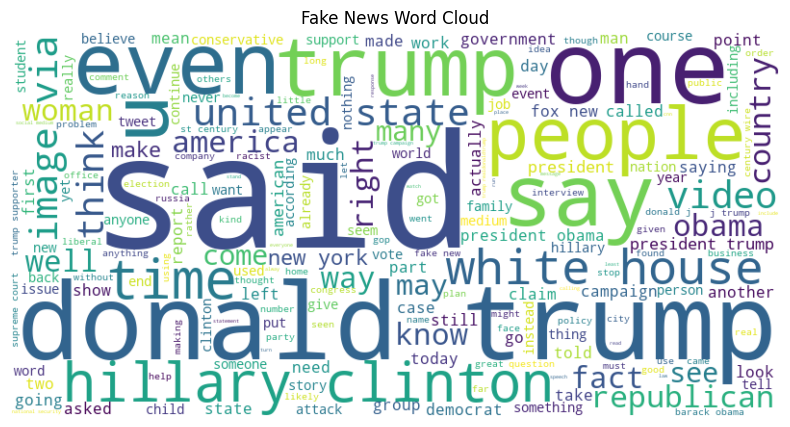

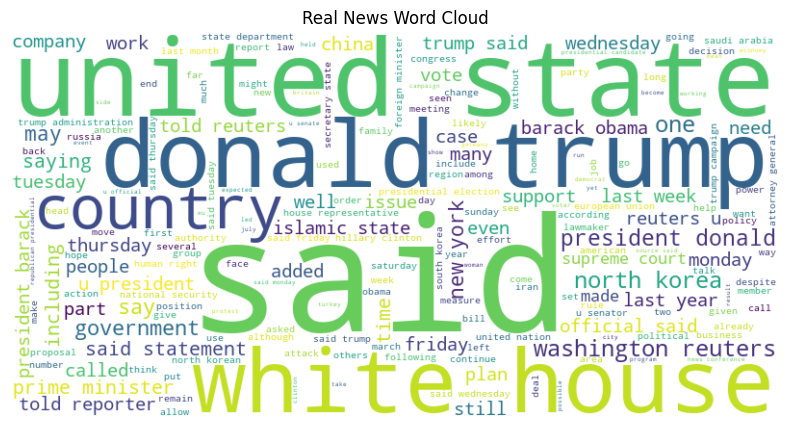

In [95]:
fake_text = " ".join(df[df['label'] == 1]['clean_content'])

wc = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Fake News Word Cloud")
plt.show()

real_text = " ".join(df[df['label'] == 0]['clean_content'])

wc = WordCloud(width=800, height=400, background_color='white').generate(real_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Real News Word Cloud")
plt.show()

In [98]:
df = df.drop(columns=['content', 'word_counts'])

In [99]:
df.sample(100)

,label,word_count,clean_content
13248,0,490,jordan begin diplomatic offensive ahead trump ...
20353,1,578,fullfrontal assault censorship canada post off...
11432,0,208,egypt hike cairo metro fare next july state ne...
16121,0,386,danish submarine owner admits dismembering bod...
5779,0,833,trump urge republican go nuclear defend high c...
...,...,...,...
2121,0,99,trump blast republican senator moral equivalen...
5194,1,500,san jose cop wrongly held black family gunpoin...
11227,1,165,laughable evelyn farkas blame russia fake news...
5346,1,395,drunken cop arrested holding fast food worker ...


# Text Representation

## Tfidf without word count

In [101]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_content'], df['label'], test_size=0.2, random_state=42
)

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_text)  # learn vocabulary here
X_test_tfidf  = tfidf.transform(X_test_text)       # use same vocab

# Modeling

In [106]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [107]:
y_pred = model.predict(X_test_tfidf)

## Evaluation

In [108]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9887372013651877
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4228
           1       0.99      0.99      0.99      4562

    accuracy                           0.99      8790
   macro avg       0.99      0.99      0.99      8790
weighted avg       0.99      0.99      0.99      8790



## Testing other models

In [113]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9360637087599545


In [114]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9943117178612059


### Among the tested models, Linear SVM achieved the highest accuracy, demonstrating its effectiveness for high-dimensional text classification. Logistic Regression also performed strongly, while Naive Bayes showed comparatively lower performance due to its independence assumption.

In [115]:
import pickle

pickle.dump(svm_model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))